In [252]:
# for EDA
import pandas as pd
import numpy as np

import matplotlib.pylab as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator

# 'ggplot' for better aesthetics
plt.style.use('ggplot')

import seaborn as sns

# for ML

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# for linear regression
from sklearn.linear_model import LinearRegression

# For the XGBoost model
from xgboost import XGBRegressor 


In [253]:
pd.set_option('display.max_columns',200)

In [254]:
df=pd.read_csv("C:/Users/mohit/Desktop/capstone project/tata_power_modified_patterns.csv")

In [255]:
df.shape

(105264, 28)

In [256]:
df.head(3)

,timestamp,region,day_of_week,month,holiday_flag,day_type,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%
0,01-01-2023 00:00,Mumbai,Sunday,1,0,Weekend,26.884441,45.739484,0.000000,0.0,0.000000,179.131751,280.165048,459.296799,14.182997,12.629283,0.000000,0.000000,50.195235,224.806153,230,-2.258194,0.996301,0.869633,67.321351,686723,22450,39.126688
1,01-01-2023 01:00,Mumbai,Sunday,1,0,Weekend,28.325968,48.624567,1.908234,0.0,196.945317,207.692798,309.077183,516.769981,11.895278,11.155567,0.168918,6.897531,49.978635,224.581335,230,-2.355941,0.922105,0.869647,67.140755,686723,22507,39.126688
2,01-01-2023 02:00,Mumbai,Sunday,1,0,Weekend,28.296852,57.157680,2.421967,0.0,443.984506,204.636827,298.119795,502.756623,13.486184,10.984116,0.380803,8.754527,50.069858,233.783459,230,1.644982,0.938103,0.869661,67.183766,686723,22526,39.126688


In [257]:
df.columns

Index(['timestamp', 'region', 'day_of_week', 'month', 'holiday_flag',
       'day_type', 'temperature_c', 'humidity_%', 'wind_speed_mps',
       'rainfall_mm', 'solar_irradiance_wm2', 'residential_load_mw',
       'industrial_load_mw', 'total_load_mw', 'ev_charging_load_mw',
       'battery_storage_mw', 'solar_generation_mw', 'wind_generation_mw',
       'grid_frequency_hz', 'grid_voltage_v', 'nominal_voltage_v',
       'voltage_fluctuation_%', 'power_factor', 'appliance_saturation_index',
       'smart_meter_penetration_%', 'region_population',
       'electric_vehicle_count', 'renewable_share_target_%'],
      dtype='object')

In [258]:
df.describe()

,month,holiday_flag,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%
count,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.0,105264.000000,105264.000000,105264.000000,105264.000000,1.052640e+05,105264.000000,105264.000000
mean,6.519836,0.002736,30.871772,54.990941,2.007768,0.240371,317.926746,209.741478,262.286860,472.028338,18.913525,7.512837,0.325544,7.173341,49.999910,227.350197,230.0,-1.152088,0.949449,0.877599,77.502332,1.837410e+06,185385.535834,38.303030
std,3.449567,0.052235,4.659756,11.703065,0.980533,0.875749,385.906723,34.154529,46.521426,75.608183,9.089649,6.352251,0.401682,3.581548,0.100435,4.996079,0.0,2.172208,0.028804,0.036034,11.957559,8.766759e+05,37201.708160,8.025618
min,1.000000,0.000000,17.942351,30.000000,0.000000,0.000000,0.000000,105.245114,112.761552,254.087665,9.365697,-16.573227,0.000000,0.000000,49.558482,210.000000,230.0,-8.695652,0.850000,0.827415,59.500002,6.787720e+05,10224.000000,25.178637
25%,4.000000,0.000000,26.961975,45.178711,1.322857,0.000000,0.000000,183.674104,228.205587,414.937871,13.629080,6.184541,0.000000,4.670426,49.932284,223.966359,230.0,-2.623322,0.929946,0.852290,67.003549,6.867230e+05,200000.000000,31.446692
50%,7.000000,0.000000,30.863408,54.980053,1.998385,0.000000,0.203573,208.657241,259.450892,469.095412,14.756715,9.255380,0.000169,7.082021,49.999849,227.348714,230.0,-1.152733,0.950050,0.867771,77.500007,2.035706e+06,200000.000000,39.473659
75%,10.000000,0.000000,34.841897,64.850960,2.674177,0.052535,706.962775,234.049413,293.985932,525.454518,16.585794,11.604643,0.709187,9.545443,50.067677,230.747794,230.0,0.325128,0.970377,0.889047,87.993244,2.735241e+06,200000.000000,45.043883
max,12.000000,1.000000,42.581695,88.382015,6.329187,19.108328,999.999917,333.466317,453.882516,773.357919,43.926860,20.000000,1.273524,25.288309,50.425333,240.000000,230.0,4.347826,1.000000,0.966397,95.499999,2.852315e+06,200000.000000,49.201652


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105264 entries, 0 to 105263
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   timestamp                   105264 non-null  object 
 1   region                      105264 non-null  object 
 2   day_of_week                 105264 non-null  object 
 3   month                       105264 non-null  int64  
 4   holiday_flag                105264 non-null  int64  
 5   day_type                    105264 non-null  object 
 6   temperature_c               105264 non-null  float64
 7   humidity_%                  105264 non-null  float64
 8   wind_speed_mps              105264 non-null  float64
 9   rainfall_mm                 105264 non-null  float64
 10  solar_irradiance_wm2        105264 non-null  float64
 11  residential_load_mw         105264 non-null  float64
 12  industrial_load_mw          105264 non-null  float64
 13  total_load_mw 

In [260]:
df.dtypes

timestamp                      object
region                         object
day_of_week                    object
month                           int64
holiday_flag                    int64
day_type                       object
temperature_c                 float64
humidity_%                    float64
wind_speed_mps                float64
rainfall_mm                   float64
solar_irradiance_wm2          float64
residential_load_mw           float64
industrial_load_mw            float64
total_load_mw                 float64
ev_charging_load_mw           float64
battery_storage_mw            float64
solar_generation_mw           float64
wind_generation_mw            float64
grid_frequency_hz             float64
grid_voltage_v                float64
nominal_voltage_v               int64
voltage_fluctuation_%         float64
power_factor                  float64
appliance_saturation_index    float64
smart_meter_penetration_%     float64
region_population               int64
electric_veh

In [261]:
df.index


RangeIndex(start=0, stop=105264, step=1)

In [262]:
'''df['timestamp'] = pd.to_datetime(df['timestamp'], infer_datetime_format=True, errors='coerce')

# have to change the format for each column


df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

df = df.set_index('timestamp')

'''

"df['timestamp'] = pd.to_datetime(df['timestamp'], infer_datetime_format=True, errors='coerce')\n\n# have to change the format for each column\n\n\ndf['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)\n\ndf = df.set_index('timestamp')\n\n"

In [263]:
# Convert the 'timestamp' column to datetime objects. 'dayfirst=True' is used
# because the format 'DD-MM-YYYY HH:MM' is implied by the head output.
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Set the 'timestamp' column as the DataFrame's index
df = df.set_index('timestamp')

In [264]:
df.dtypes

region                         object
day_of_week                    object
month                           int64
holiday_flag                    int64
day_type                       object
temperature_c                 float64
humidity_%                    float64
wind_speed_mps                float64
rainfall_mm                   float64
solar_irradiance_wm2          float64
residential_load_mw           float64
industrial_load_mw            float64
total_load_mw                 float64
ev_charging_load_mw           float64
battery_storage_mw            float64
solar_generation_mw           float64
wind_generation_mw            float64
grid_frequency_hz             float64
grid_voltage_v                float64
nominal_voltage_v               int64
voltage_fluctuation_%         float64
power_factor                  float64
appliance_saturation_index    float64
smart_meter_penetration_%     float64
region_population               int64
electric_vehicle_count          int64
renewable_sh

In [265]:
df.head(2)

,region,day_of_week,month,holiday_flag,day_type,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,Mumbai,Sunday,1,0,Weekend,26.884441,45.739484,0.000000,0.0,0.000000,179.131751,280.165048,459.296799,14.182997,12.629283,0.000000,0.000000,50.195235,224.806153,230,-2.258194,0.996301,0.869633,67.321351,686723,22450,39.126688
2023-01-01 01:00:00,Mumbai,Sunday,1,0,Weekend,28.325968,48.624567,1.908234,0.0,196.945317,207.692798,309.077183,516.769981,11.895278,11.155567,0.168918,6.897531,49.978635,224.581335,230,-2.355941,0.922105,0.869647,67.140755,686723,22507,39.126688


In [266]:
df.isna().sum()

region                        0
day_of_week                   0
month                         0
holiday_flag                  0
day_type                      0
temperature_c                 0
humidity_%                    0
wind_speed_mps                0
rainfall_mm                   0
solar_irradiance_wm2          0
residential_load_mw           0
industrial_load_mw            0
total_load_mw                 0
ev_charging_load_mw           0
battery_storage_mw            0
solar_generation_mw           0
wind_generation_mw            0
grid_frequency_hz             0
grid_voltage_v                0
nominal_voltage_v             0
voltage_fluctuation_%         0
power_factor                  0
appliance_saturation_index    0
smart_meter_penetration_%     0
region_population             0
electric_vehicle_count        0
renewable_share_target_%      0
dtype: int64

In [267]:
df.duplicated().sum()

np.int64(0)

In [268]:
#to check for duplicated with 'some' similar values
# df.loc[df.duplicated(subset=['timestamp'])]

### Exploratory Data Analysis (EDA)

Let's visualize some key trends and relationships in the data to gain insights.


BASIC ANALYSIS

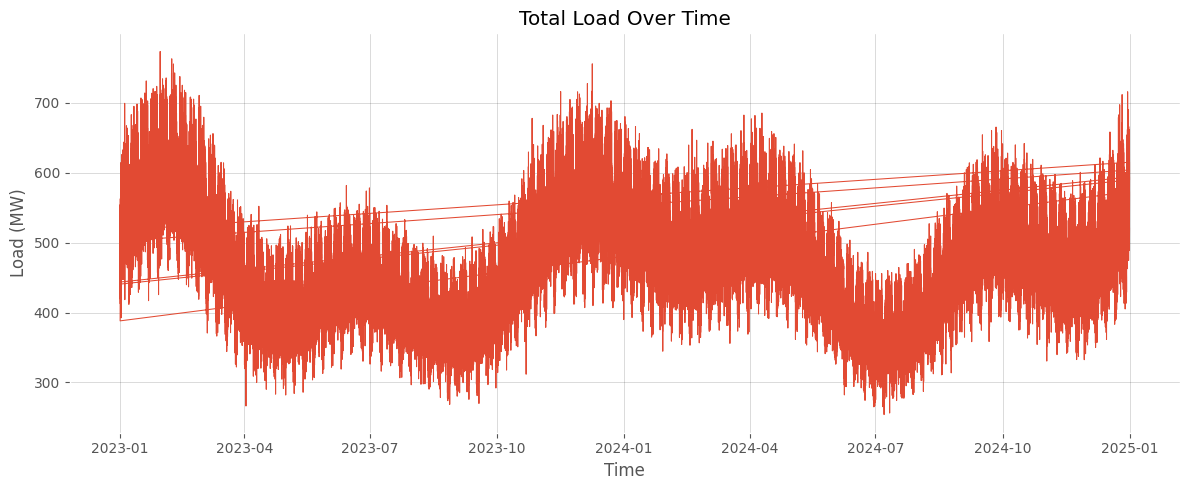

In [269]:
#Total Load Over Time

plt.figure(figsize=(12,5))
plt.plot(df.index, df['total_load_mw'], linewidth = 0.75)
plt.title("Total Load Over Time")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.tight_layout()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()



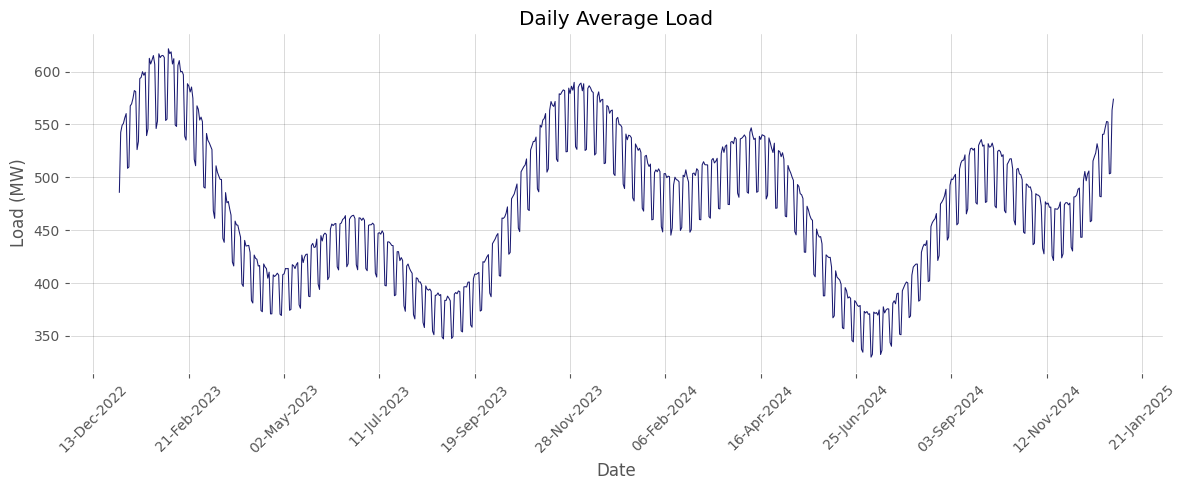

In [270]:
#Daily Average Load

daily_avg = df['total_load_mw'].resample('D').mean()
plt.figure(figsize=(12,5))
plt.plot(daily_avg, linewidth = 0.75, color= 'midnightblue')

# More detailed x-axis
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=10))

# Format the actual date labels
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))

plt.title("Daily Average Load")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


In [271]:

'''

plt.figure(figsize=(8,5))
plt.plot(df['temperature_c'], df['total_load_mw'])

# Zooming out: set the min/max for both axes
plt.xlim(df['temperature_c'].min() - 2, df['temperature_c'].max() + 2)
plt.ylim(df['total_load_mw'].min() - 300, df['total_load_mw'].max() + 200)

plt.title("Temperature vs Load")
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (MW)")

plt.tight_layout()
plt.show()'''




'\n\nplt.figure(figsize=(8,5))\nplt.plot(df[\'temperature_c\'], df[\'total_load_mw\'])\n\n# Zooming out: set the min/max for both axes\nplt.xlim(df[\'temperature_c\'].min() - 2, df[\'temperature_c\'].max() + 2)\nplt.ylim(df[\'total_load_mw\'].min() - 300, df[\'total_load_mw\'].max() + 200)\n\nplt.title("Temperature vs Load")\nplt.xlabel("Temperature (°C)")\nplt.ylabel("Load (MW)")\n\nplt.tight_layout()\nplt.show()'

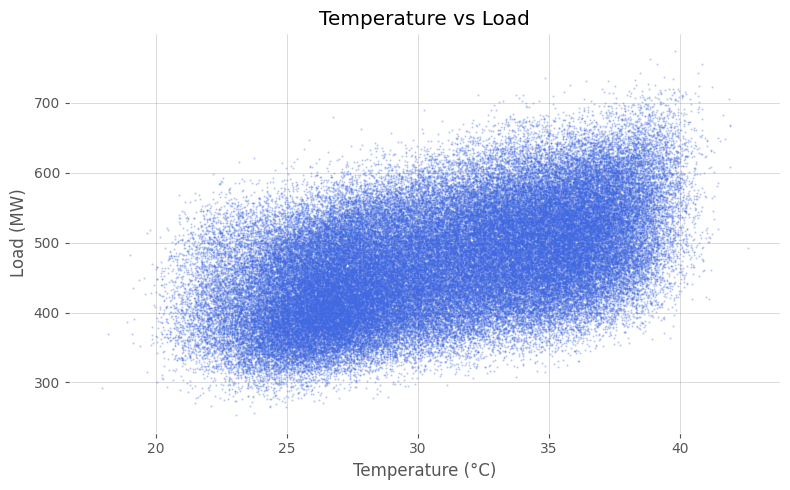

In [272]:
#Temperature vs Load

# downsample every Nth point
#N = 40  # keep every 40th row
#df_small = df.iloc[::N]

plt.figure(figsize=(8,5))


plt.scatter(df['temperature_c'], df['total_load_mw'], s=1, alpha=0.25, color='royalblue')

plt.title("Temperature vs Load")
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (MW)")
plt.tight_layout()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


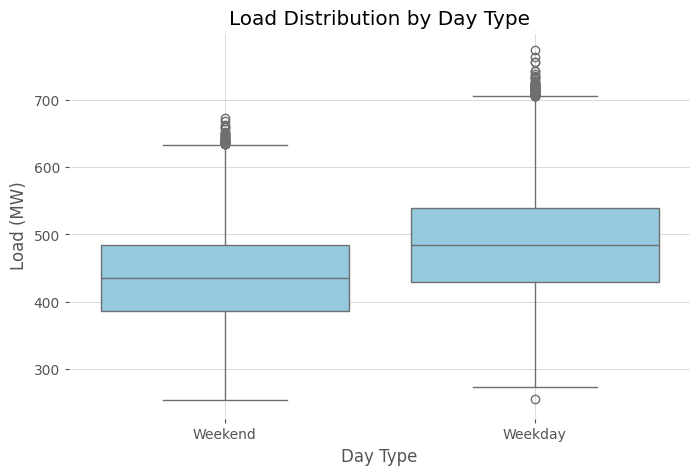

In [273]:
#Load Distribution by Day Type

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='day_type', y='total_load_mw', color = 'skyblue')
plt.title("Load Distribution by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Load (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


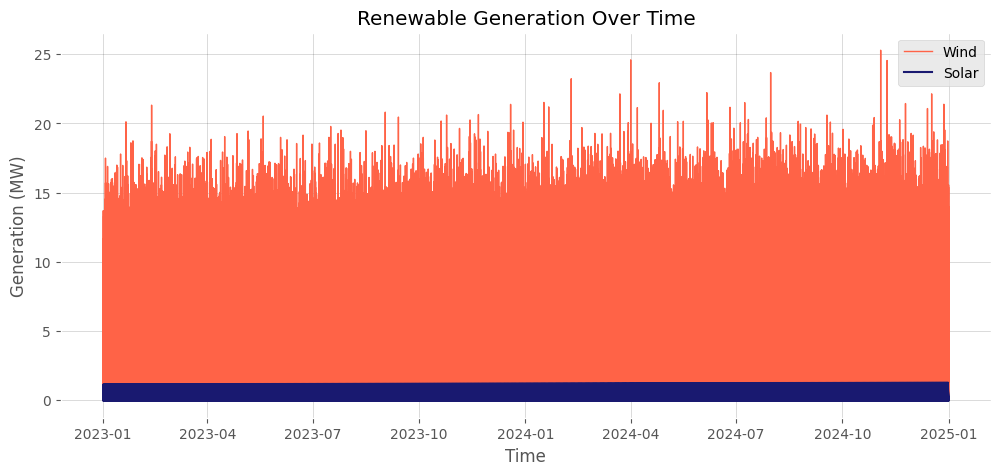

In [274]:
#Renewable Generation Over Time

plt.figure(figsize=(12,5))

plt.plot(df.index, df['wind_generation_mw'], label="Wind", color = 'tomato', linewidth = 1)
plt.plot(df.index, df['solar_generation_mw'], label="Solar", color='midnightblue')

plt.title("Renewable Generation Over Time")
plt.xlabel("Time")
plt.ylabel("Generation (MW)")
plt.legend()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


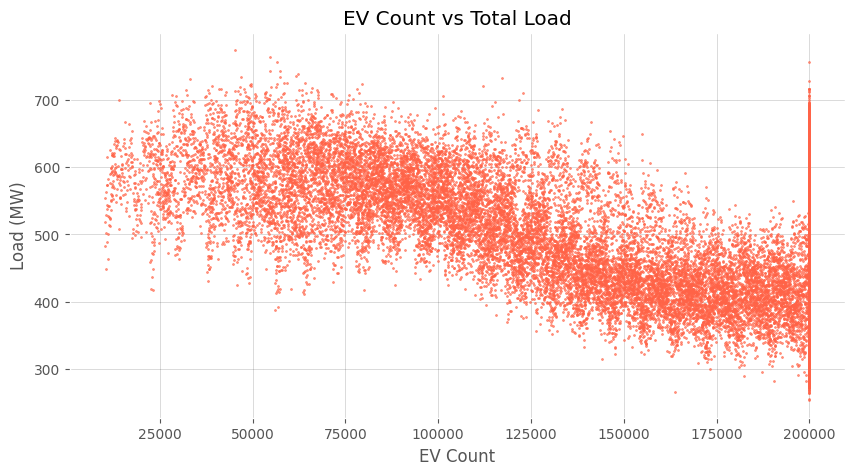

In [275]:
#EV Count vs Total Load

plt.figure(figsize=(10,5))
plt.scatter(df['electric_vehicle_count'], df['total_load_mw'], s=2, alpha=0.7, color='tomato')
plt.title("EV Count vs Total Load")
plt.xlabel("EV Count")
plt.ylabel("Load (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


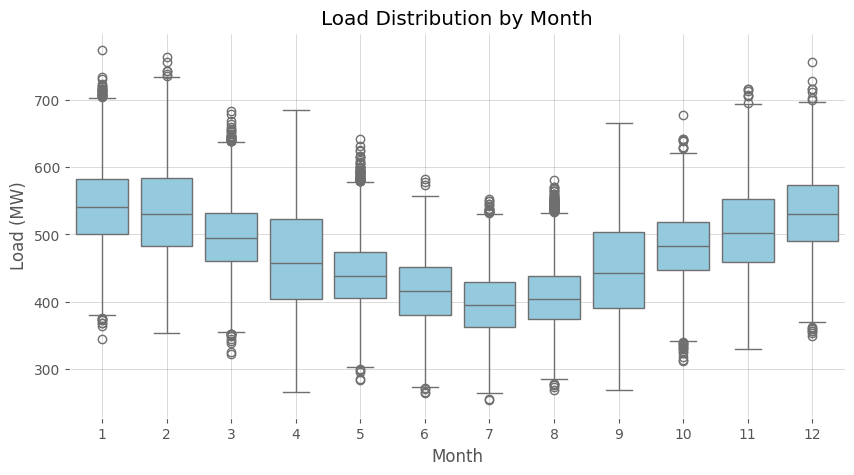

In [276]:
#Load Distribution by Month

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='month', y='total_load_mw', color='skyblue')
plt.title("Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Load (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


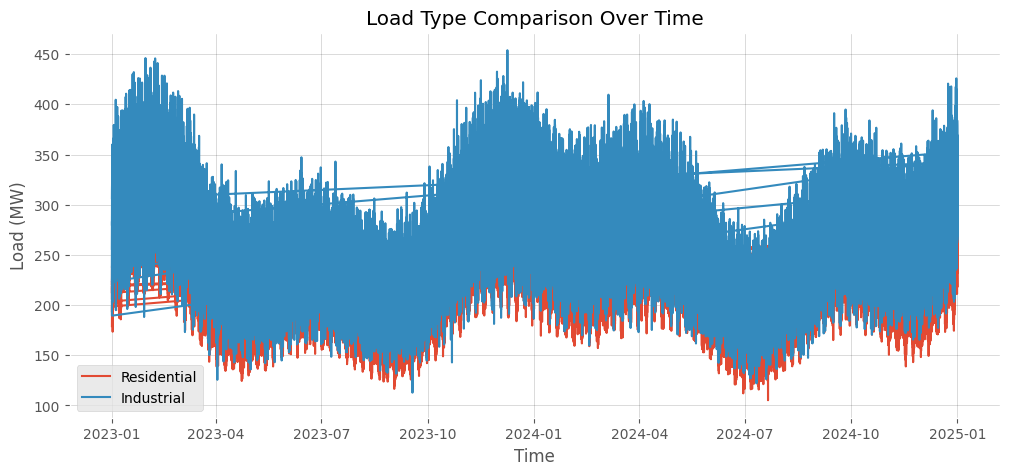

In [277]:
#Load Type Comparison Over Time

plt.figure(figsize=(12,5))
plt.plot(df.index, df['residential_load_mw'], label="Residential")

plt.plot(df.index, df['industrial_load_mw'], label="Industrial")
plt.title("Load Type Comparison Over Time")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


## ANALYSIS BASED ON KPIs



In [278]:
# Average Residential Load

avg_res_load = df['residential_load_mw'].mean()
print('Average Residential Load:', avg_res_load)


Average Residential Load: 209.74147788182324


In [279]:
# Peak Load Demand

peak_load = df['total_load_mw'].max()
print('Peak Load Demand: ',peak_load)

Peak Load Demand:  773.3579186521546


In [280]:
# load Factor

avg_load = df['total_load_mw'].mean()
peak_load = df['total_load_mw'].max()

load_factor = (avg_load / peak_load) * 100

print('Load Factor: ',load_factor)


Load Factor:  61.03620677114642


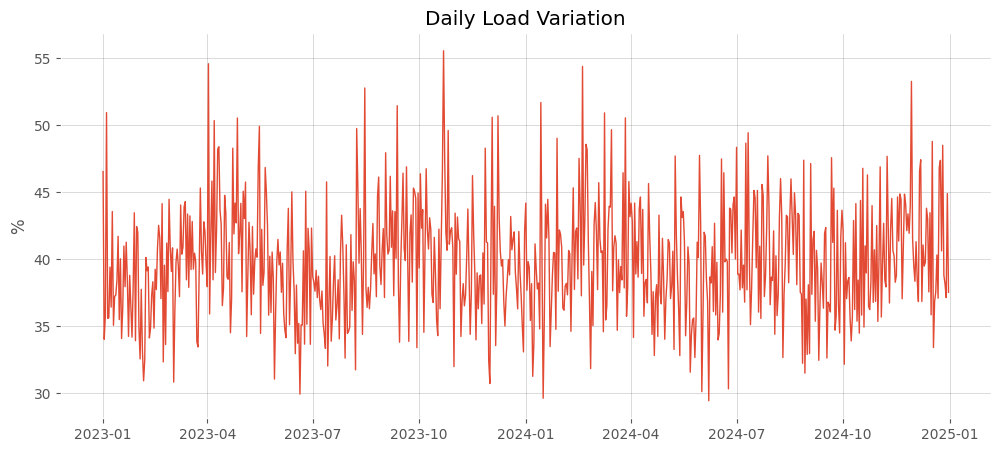

In [281]:
#Daily Load Variation

daily = df['total_load_mw'].resample('D').agg(['min','max','mean'])
daily['variation'] = ((daily['max'] - daily['min']) / daily['mean']) * 100

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily['variation'], linewidth=1)
plt.ylabel("%")
plt.title("Daily Load Variation")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


In [282]:
# Weekends and Weekdays Average

df['weekday'] = df.index.weekday  # 0=Mon,6=Sun
weekday_avg = df[df['weekday'] < 5]['total_load_mw'].mean()
weekend_avg = df[df['weekday'] >= 5]['total_load_mw'].mean()

diff = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print('Weekdays Average: ',weekday_avg)
print('Weekend Average: ',weekend_avg)




Weekdays Average:  485.9548695163143
Weekend Average:  437.24532735298936


In [283]:
#Solar Energy Utilisation Index

solar_util = (df['solar_generation_mw'].sum() / df['total_load_mw'].sum()) * 100

print('Solar Energy Utilisation Index: ',solar_util)


Solar Energy Utilisation Index:  0.0689669828502721


In [284]:
#Correlation Between Solar Irradiance & Load Reduction

corr_solar_eff = df[['solar_irradiance_wm2', 'total_load_mw']].corr().iloc[0,1]

print('Correlation Between Solar Irradiance & Load Reduction: ',corr_solar_eff)


Correlation Between Solar Irradiance & Load Reduction:  -0.002767322910259983


In [285]:
#Correlation Between Temprature and Load

corr_temp_load = df[['temperature_c','total_load_mw']].corr().iloc[0,1]

print('Correlation Between Temprature and Load: ',corr_temp_load)


Correlation Between Temprature and Load:  0.5188131532125833


In [286]:
#Total Load due to EVs

ev_share = (df['ev_charging_load_mw'].sum() / df['residential_load_mw'].sum()) * 100

print("Total Load due to EVs: ",ev_share)


Total Load due to EVs:  9.01754167867551


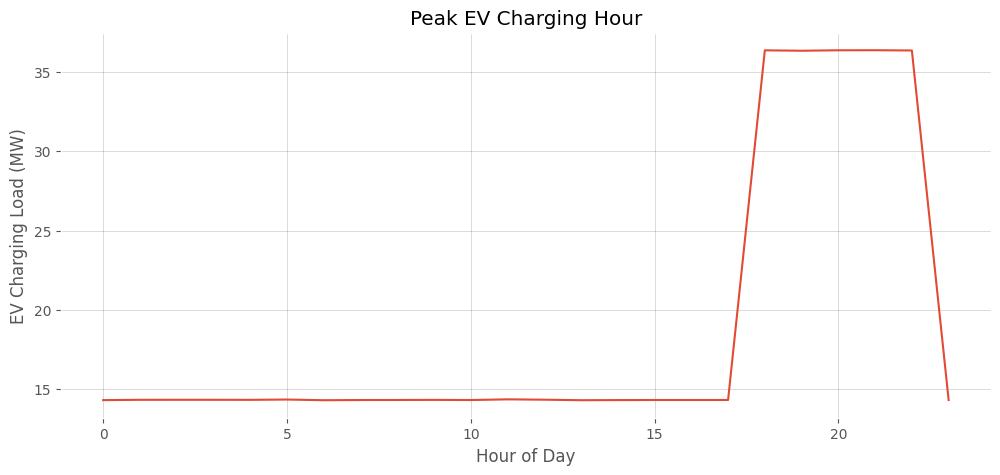

In [287]:
# Peak EV Charging Hours

df['hour'] = df.index.hour
ev_hour = df.groupby('hour')['ev_charging_load_mw'].mean()

plt.figure(figsize=(12,5))
plt.plot(ev_hour.index, ev_hour.values)
plt.title("Peak EV Charging Hour")
plt.xlabel("Hour of Day")
plt.ylabel("EV Charging Load (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


C:\Users\mohit\AppData\Local\Temp\ipykernel_12052\2332329277.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ev_monthly = df['ev_charging_load_mw'].resample('M').sum()


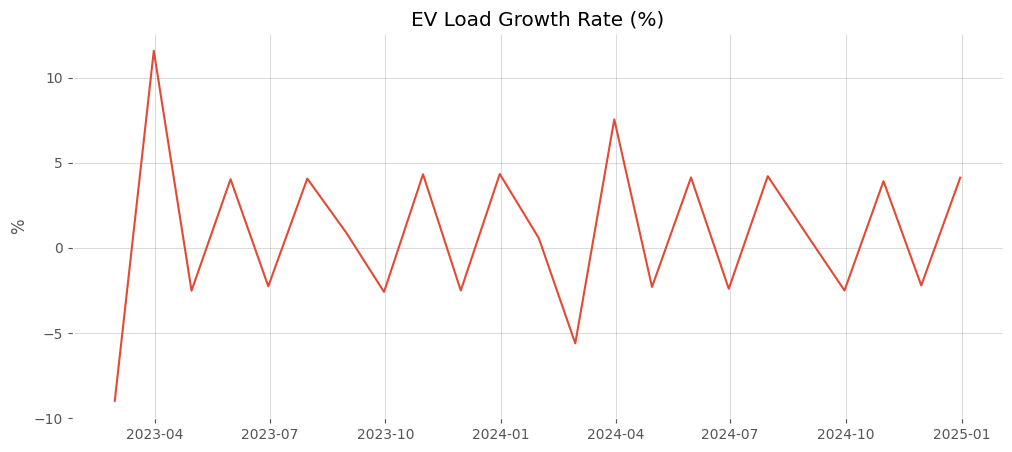

In [288]:
# EV Load Growth Rate

ev_monthly = df['ev_charging_load_mw'].resample('M').sum()
growth = ev_monthly.pct_change() * 100

plt.figure(figsize=(12,5))
plt.plot(growth.index, growth.values)
plt.title("EV Load Growth Rate (%)")
plt.ylabel("%")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


In [289]:
#Average Grid Voltage

avg_voltage = df['grid_voltage_v'].mean()

print('Average Grid Voltage: ',avg_voltage)

Average Grid Voltage:  227.35019698165848


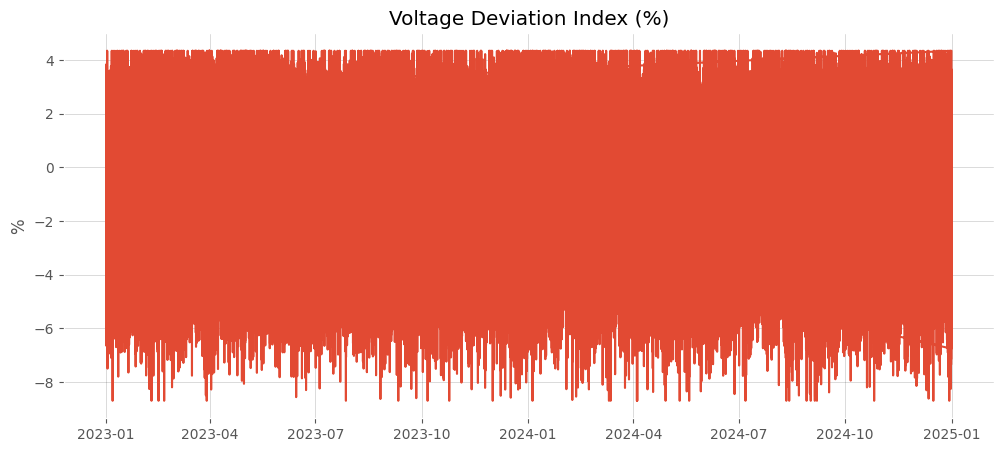

In [290]:
# Voltage Deviation Index

vdev = ((df['grid_voltage_v'] - df['nominal_voltage_v']) / df['nominal_voltage_v']) * 100

plt.figure(figsize=(12,5))
plt.plot(df.index, vdev)
plt.title("Voltage Deviation Index (%)")
plt.ylabel("%")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


In [291]:
#Correlation Between Total Load and Grid Voltage

corr_lvs = df[['total_load_mw','grid_voltage_v']].corr().iloc[0,1]

print('Correlation Between Total Load and Grid Voltage: ',corr_lvs)

Correlation Between Total Load and Grid Voltage:  -0.025983837078172794


In [292]:
#Effect of Appliance Saturation on Residential Load

corr_app_load = df[['appliance_saturation_index','residential_load_mw']].corr().iloc[0,1]

print('Effect of Appliance Saturation on Residential Load: ',corr_app_load)


Effect of Appliance Saturation on Residential Load:  -0.009761428020669533


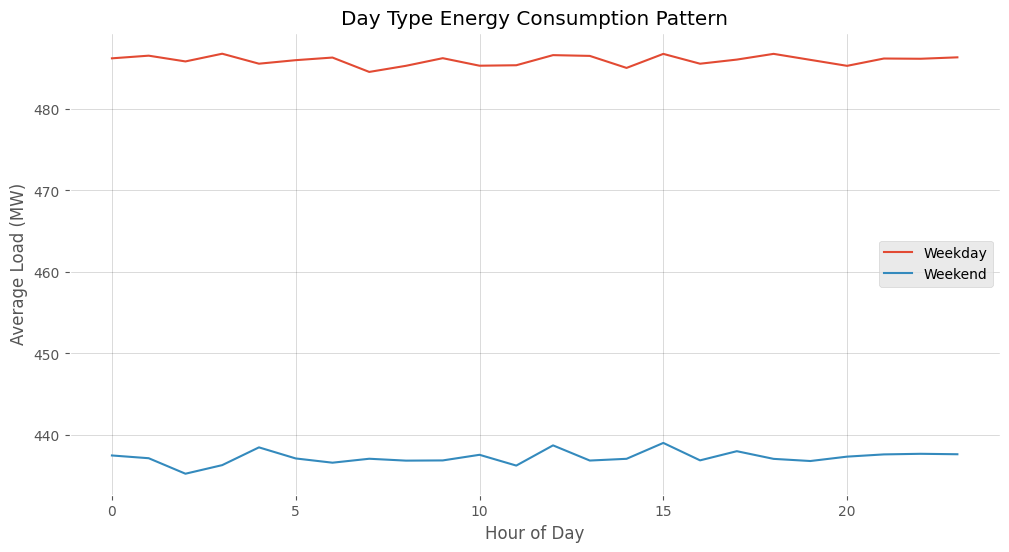

In [293]:
# Weekday vs Weekend Average Load Profile

# Extract hour and weekday
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday   # 0=Mon .. 6=Sun

# Separate weekday and weekend loads
weekday_profile = df[df['weekday'] < 5].groupby('hour')['total_load_mw'].mean()
weekend_profile = df[df['weekday'] >= 5].groupby('hour')['total_load_mw'].mean()

plt.figure(figsize=(12,6))
plt.plot(weekday_profile.index, weekday_profile.values, label='Weekday')
plt.plot(weekend_profile.index, weekend_profile.values, label='Weekend')

plt.title("Day Type Energy Consumption Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.legend()
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


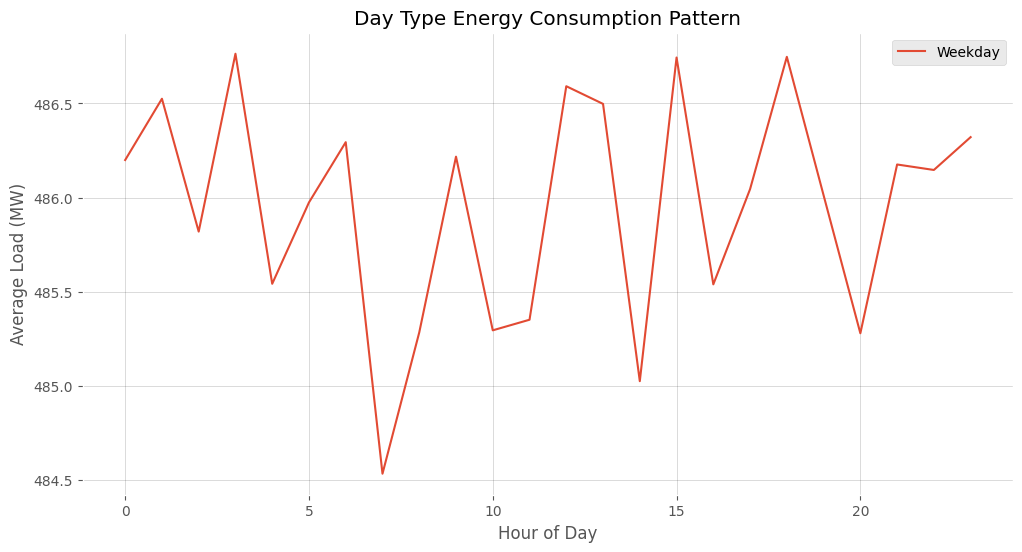

In [ ]:
# Extract hour and weekday
df['hour'] = df.index.hour
df['weekday'] = df.index.weekday   # 0=Mon .. 6=Sun

# Separate weekday and weekend loads
weekday_profile = df[df['weekday'] < 5].groupby('hour')['total_load_mw'].mean()
weekend_profile = df[df['weekday'] >= 5].groupby('hour')['total_load_mw'].mean()

plt.figure(figsize=(12,6))
plt.plot(weekday_profile.index, weekday_profile.values, label='Weekday')

plt.title("Energy Consumption Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average Load (MW)")
plt.legend()
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()

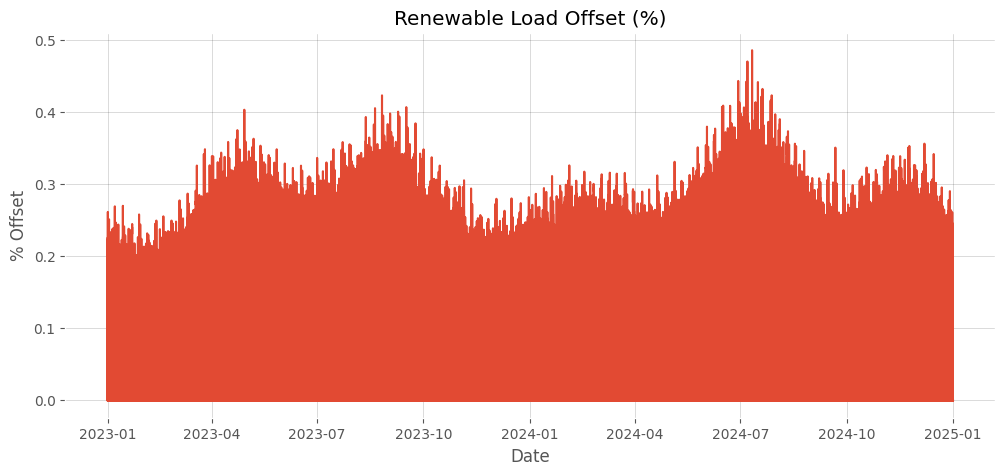

In [294]:
# Renewable Load Offset (%)

daily_offset = (df['solar_generation_mw'] / df['total_load_mw']) * 100

plt.figure(figsize=(12,5))
plt.plot(daily_offset.index, daily_offset.values)
plt.title("Renewable Load Offset (%)")
plt.ylabel("% Offset")
plt.xlabel("Date")
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


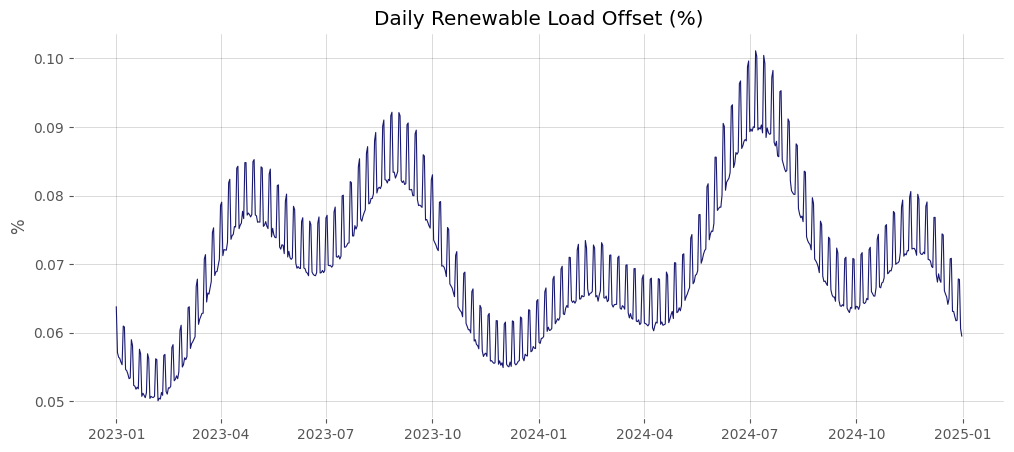

In [295]:
# Daily Renewable Load Offset

daily = df.resample('D').sum()
offset_daily = (daily['solar_generation_mw'] / daily['total_load_mw']) * 100

plt.figure(figsize=(12,5))
plt.plot(offset_daily.index, offset_daily.values, linewidth=0.8, color='midnightblue')
plt.title("Daily Renewable Load Offset (%)")
plt.ylabel("%")
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()


## ANALYSIS BASED ON CORRELATION 


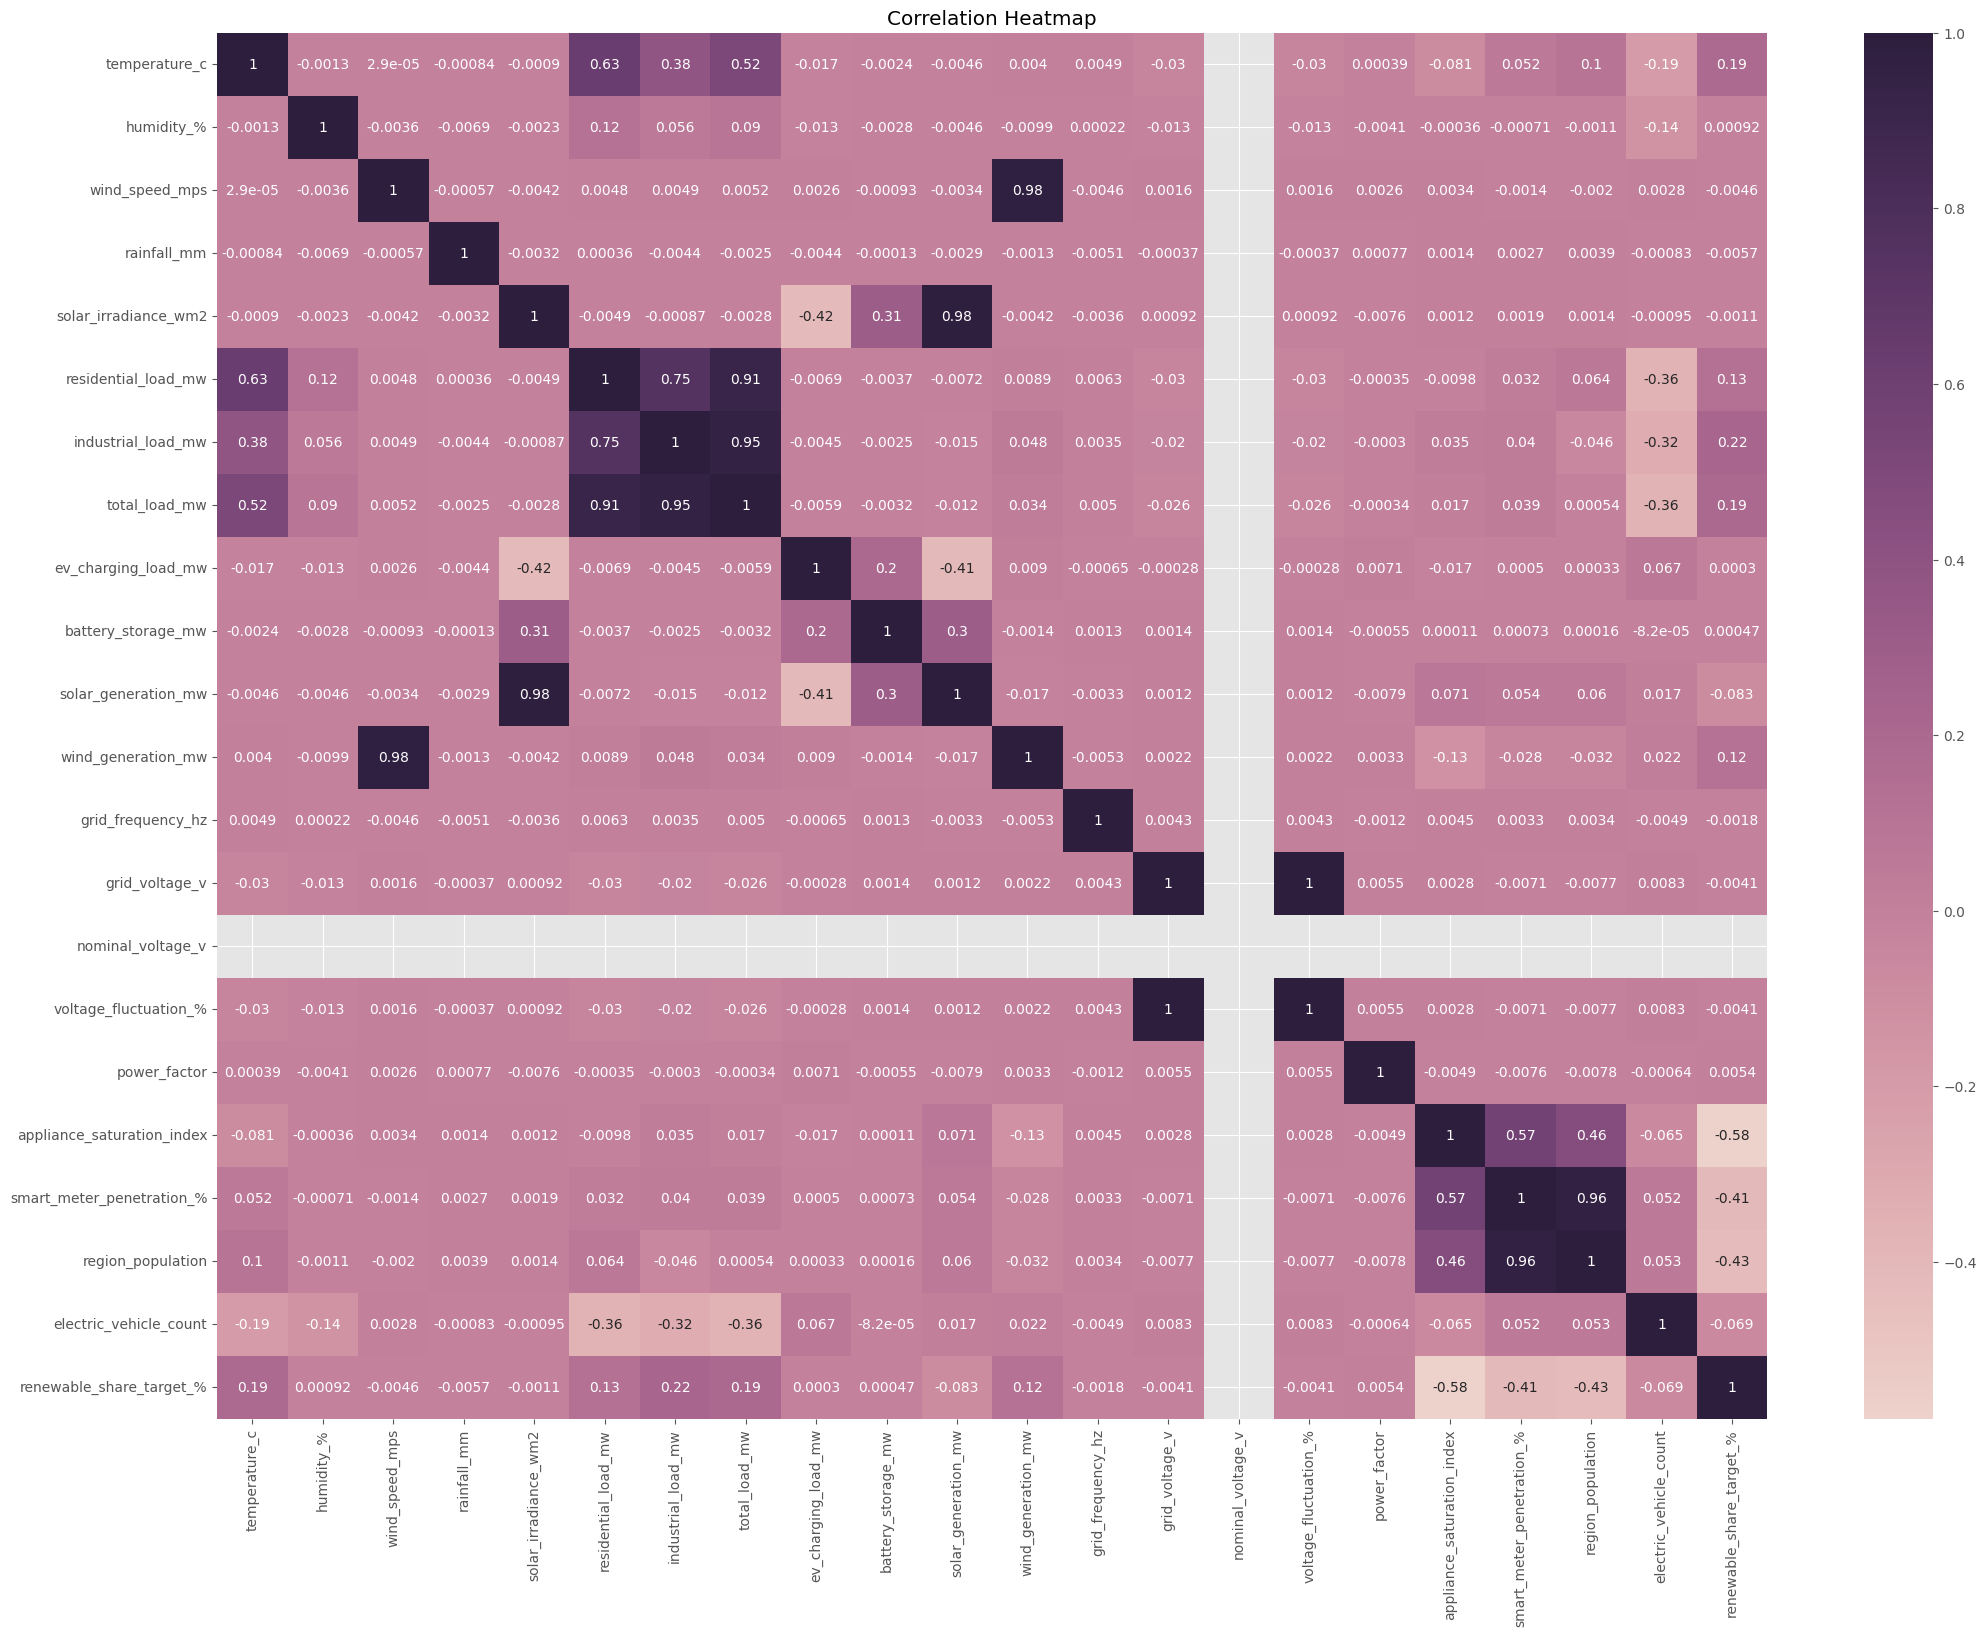

In [296]:
cols = [
    'temperature_c', 'humidity_%', 'wind_speed_mps', 'rainfall_mm',
    'solar_irradiance_wm2', 'residential_load_mw', 'industrial_load_mw',
    'total_load_mw', 'ev_charging_load_mw', 'battery_storage_mw',
    'solar_generation_mw', 'wind_generation_mw', 'grid_frequency_hz',
    'grid_voltage_v', 'nominal_voltage_v', 'voltage_fluctuation_%',
    'power_factor', 'appliance_saturation_index',
    'smart_meter_penetration_%', 'region_population',
    'electric_vehicle_count', 'renewable_share_target_%'
]

corr_df = df[cols].corr()

plt.figure(figsize=(25,18))
sns.heatmap(
    corr_df,
    annot=True
    ,cmap=sns.cubehelix_palette(as_cmap=True)
)
plt.title("Correlation Heatmap")
plt.show()

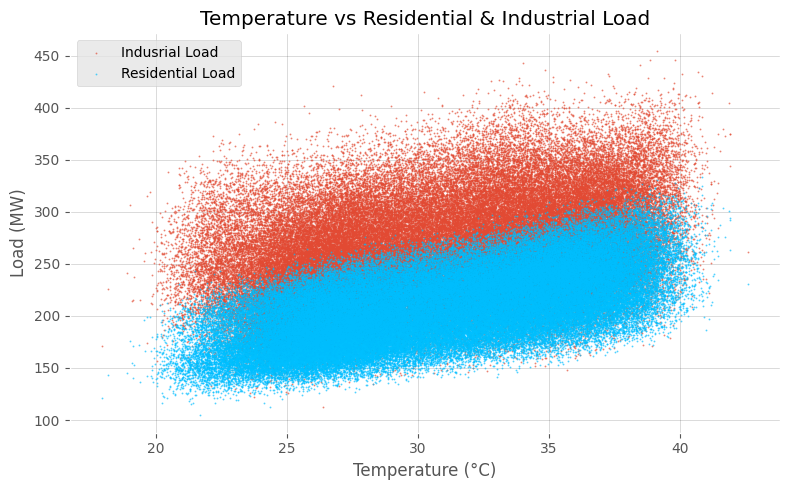

In [297]:
# Temperature vs Residential Load

plt.figure(figsize=(8,5))
plt.scatter(df['temperature_c'], df['industrial_load_mw'], s=0.8, alpha=0.5,label="Indusrial Load")
plt.scatter(df['temperature_c'], df['residential_load_mw'], s=0.8,alpha=0.5, label="Residential Load", color='deepskyblue')
plt.title("Temperature vs Residential & Industrial Load")
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (MW)")
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.legend()
plt.tight_layout()
plt.show()

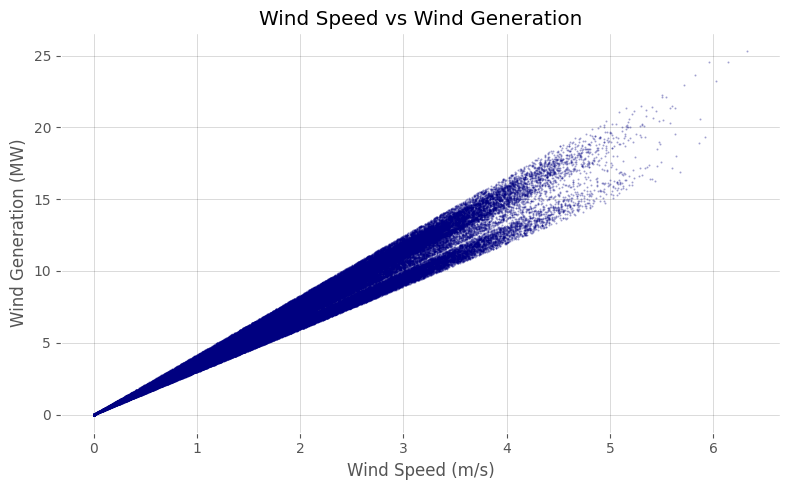

In [298]:
# Wind Speed vs Wind Generation

plt.figure(figsize=(8,5))
plt.scatter(df['wind_speed_mps'], df['wind_generation_mw'], s=1, alpha=0.25, color='navy')
plt.title("Wind Speed vs Wind Generation")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Wind Generation (MW)")
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )

plt.tight_layout()
plt.show()

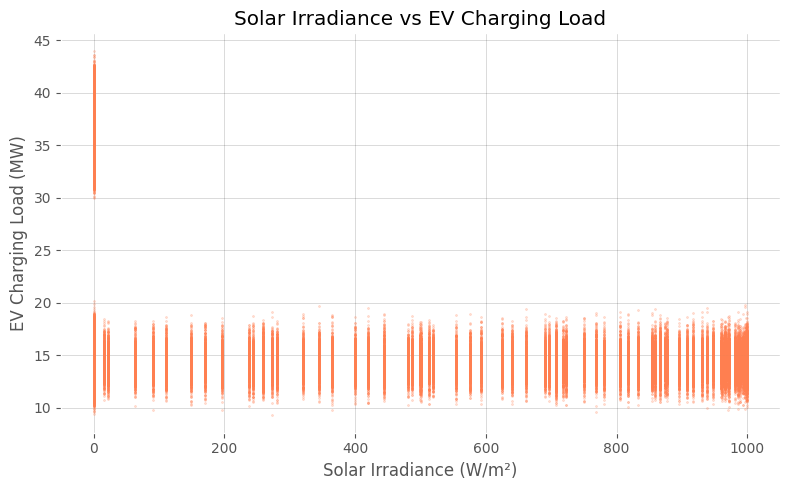

In [299]:
# Solar Irradiance vs EV Charging Load

plt.figure(figsize=(8,5))
plt.scatter(df['solar_irradiance_wm2'], df['ev_charging_load_mw'], s=2, alpha=0.25, color='coral')
plt.title("Solar Irradiance vs EV Charging Load")
plt.xlabel("Solar Irradiance (W/m²)")
plt.ylabel("EV Charging Load (MW)")
plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.tight_layout()
plt.show()

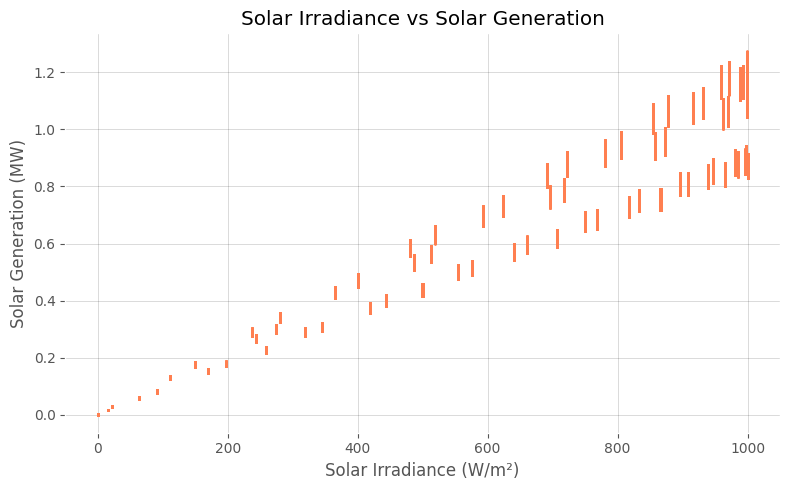

In [300]:
# Solar Irradiance vs Solar Generation

plt.figure(figsize=(8,5))
plt.scatter(df['solar_irradiance_wm2'], df['solar_generation_mw'], s=2, color = 'coral')
plt.title("Solar Irradiance vs Solar Generation")
plt.xlabel("Solar Irradiance (W/m²)")
plt.ylabel("Solar Generation (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.tight_layout()
plt.show()

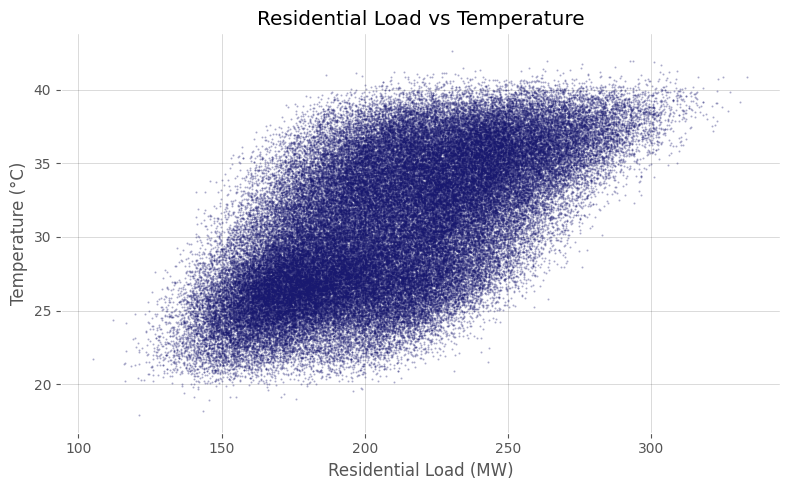

In [301]:
# Residential Load vs Temperature (same as #1 but reversed axes)

plt.figure(figsize=(8,5))
plt.scatter(df['residential_load_mw'], df['temperature_c'], s=1, alpha=0.25, color='midnightblue')
plt.title("Residential Load vs Temperature")
plt.xlabel("Residential Load (MW)")
plt.ylabel("Temperature (°C)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.tight_layout()
plt.show()

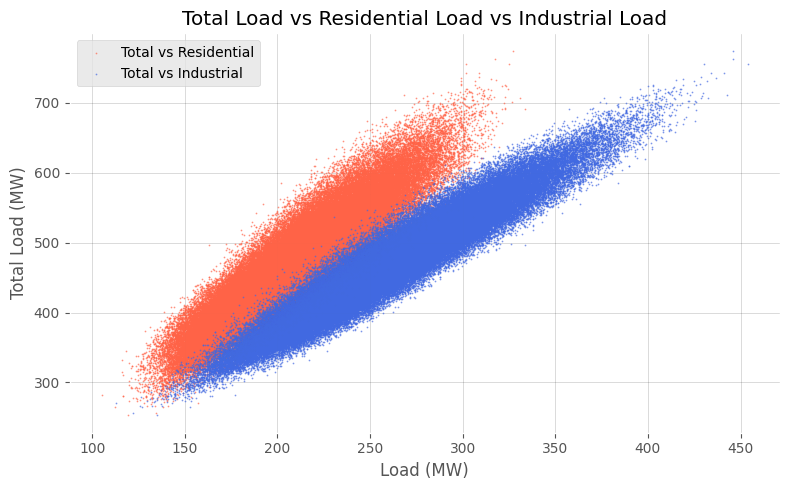

In [302]:
# Total Load vs Residential Load vs Industrial Load

plt.figure(figsize=(8,5))
plt.scatter(df['residential_load_mw'], df['total_load_mw'], s=0.7, alpha=0.5, label="Total vs Residential", color= 'tomato')
plt.scatter(df['industrial_load_mw'], df['total_load_mw'], s=0.7, alpha=0.5,label="Total vs Industrial", color='royalblue')
plt.title("Total Load vs Residential Load vs Industrial Load")
plt.xlabel("Load (MW)")
plt.ylabel("Total Load (MW)")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.legend()
plt.tight_layout()
plt.show()

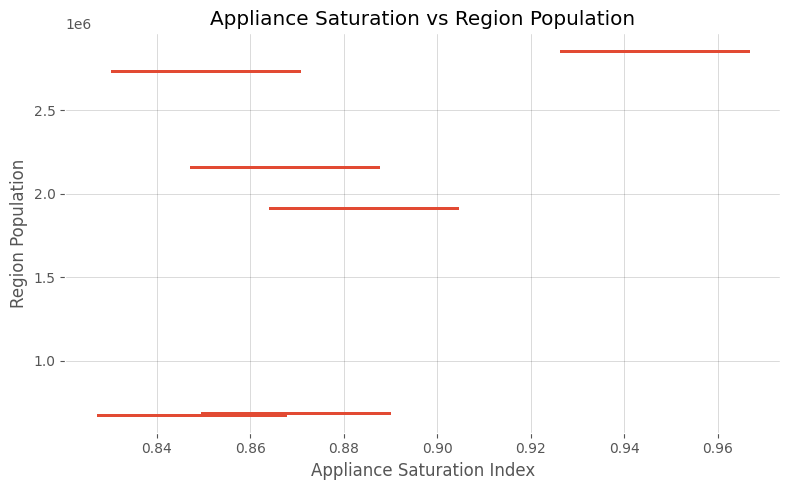

In [303]:
# Appliance Saturation vs Region Population

plt.figure(figsize=(8,5))
plt.scatter(df['appliance_saturation_index'], df['region_population'], s=1)
plt.title("Appliance Saturation vs Region Population")
plt.xlabel("Appliance Saturation Index")
plt.ylabel("Region Population")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.tight_layout()
plt.show()

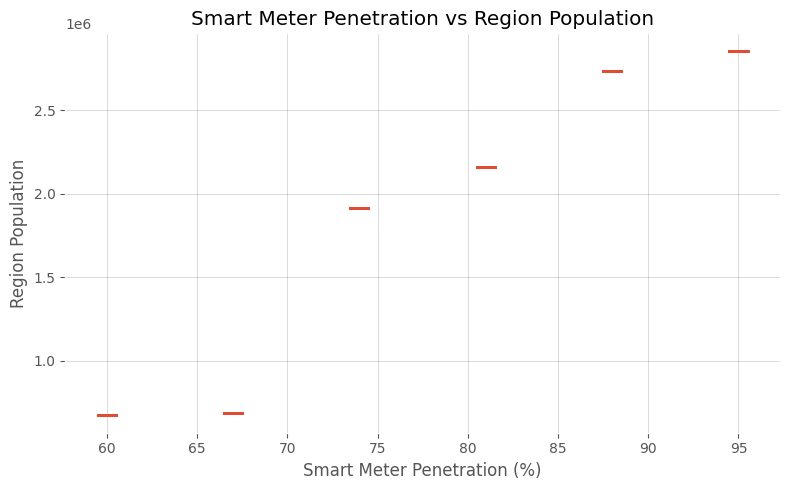

In [304]:
# Smart Meter Penetration vs Region Population

plt.figure(figsize=(8,5))
plt.scatter(df['smart_meter_penetration_%'], df['region_population'], s=1)
plt.title("Smart Meter Penetration vs Region Population")
plt.xlabel("Smart Meter Penetration (%)")
plt.ylabel("Region Population")

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.tight_layout()
plt.show()

In [305]:

# Select features and target

base_features = [
    "temperature_c", "humidity_%", "rainfall_mm",
    "solar_irradiance_wm2", "day_type", "month", "holiday_flag", 'solar_generation_mw', 'wind_generation_mw','voltage_fluctuation_%','renewable_share_target_%', 'appliance_saturation_index', 'smart_meter_penetration_%'
]

target = "total_load_mw"


In [306]:

df_ml = df.copy()

In [307]:
df_ml.drop("day_of_week", axis=1, inplace=True)

In [308]:
# encoding for weekends and weekdays

df_ml["day_type"] = df_ml["day_type"].map({"Weekday": 0, "Weekend": 1})

In [309]:
# Checking string columns

string_cols = df_ml.select_dtypes(include="object").columns
print(string_cols)


Index(['region'], dtype='object')


In [310]:
df_ml.columns

Index(['region', 'month', 'holiday_flag', 'day_type', 'temperature_c',
       'humidity_%', 'wind_speed_mps', 'rainfall_mm', 'solar_irradiance_wm2',
       'residential_load_mw', 'industrial_load_mw', 'total_load_mw',
       'ev_charging_load_mw', 'battery_storage_mw', 'solar_generation_mw',
       'wind_generation_mw', 'grid_frequency_hz', 'grid_voltage_v',
       'nominal_voltage_v', 'voltage_fluctuation_%', 'power_factor',
       'appliance_saturation_index', 'smart_meter_penetration_%',
       'region_population', 'electric_vehicle_count',
       'renewable_share_target_%', 'weekday', 'hour'],
      dtype='object')

In [311]:
df_ml.drop('hour', axis=1)

,region,month,holiday_flag,day_type,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%,weekday
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,Mumbai,1,0,1,26.884441,45.739484,0.000000,0.000000,0.000000,179.131751,280.165048,459.296799,14.182997,12.629283,0.000000,0.000000,50.195235,224.806153,230,-2.258194,0.996301,0.869633,67.321351,686723,22450,39.126688,6
2023-01-01 01:00:00,Mumbai,1,0,1,28.325968,48.624567,1.908234,0.000000,196.945317,207.692798,309.077183,516.769981,11.895278,11.155567,0.168918,6.897531,49.978635,224.581335,230,-2.355941,0.922105,0.869647,67.140755,686723,22507,39.126688,6
2023-01-01 02:00:00,Mumbai,1,0,1,28.296852,57.157680,2.421967,0.000000,443.984506,204.636827,298.119795,502.756623,13.486184,10.984116,0.380803,8.754527,50.069858,233.783459,230,1.644982,0.938103,0.869661,67.183766,686723,22526,39.126688,6
2023-01-01 03:00:00,Mumbai,1,0,1,29.039070,57.812578,2.307619,0.000000,660.766885,207.896736,326.578611,534.475348,13.852248,15.149071,0.566739,8.341246,49.982073,233.974838,230,1.728190,0.982882,0.869676,67.165819,686723,22612,39.126688,6
2023-01-01 04:00:00,Mumbai,1,0,1,27.458422,47.206830,0.689353,0.000000,832.519093,185.122870,234.093951,419.216821,13.284986,5.386399,0.714055,2.491786,49.966179,231.207804,230,0.525132,0.955699,0.869690,66.548631,686723,22656,39.126688,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,Hyderabad,12,0,0,27.785733,57.931660,2.283950,0.239878,0.000000,264.323454,264.999265,529.322718,40.068803,9.472971,0.000000,7.631433,49.997272,224.974510,230,-2.184996,0.978795,0.884187,74.452790,1913184,200000,25.178637,1
2024-12-31 20:00:00,Hyderabad,12,0,0,30.413824,47.472942,2.533146,7.167966,0.000000,236.296466,286.057073,522.353539,39.967319,9.425420,0.000000,8.464125,49.958075,220.458700,230,-4.148391,0.910713,0.884202,73.644631,1913184,200000,25.178637,1
2024-12-31 21:00:00,Hyderabad,12,0,0,29.414805,56.081601,1.760198,0.755976,0.000000,257.560341,302.546855,560.107196,40.948733,12.214156,0.000000,5.881469,49.945387,221.279161,230,-3.791669,0.929709,0.884216,73.500700,1913184,200000,25.178637,1


In [312]:
df_ml.drop('weekday', axis=1)

,region,month,holiday_flag,day_type,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%,hour
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,Mumbai,1,0,1,26.884441,45.739484,0.000000,0.000000,0.000000,179.131751,280.165048,459.296799,14.182997,12.629283,0.000000,0.000000,50.195235,224.806153,230,-2.258194,0.996301,0.869633,67.321351,686723,22450,39.126688,0
2023-01-01 01:00:00,Mumbai,1,0,1,28.325968,48.624567,1.908234,0.000000,196.945317,207.692798,309.077183,516.769981,11.895278,11.155567,0.168918,6.897531,49.978635,224.581335,230,-2.355941,0.922105,0.869647,67.140755,686723,22507,39.126688,1
2023-01-01 02:00:00,Mumbai,1,0,1,28.296852,57.157680,2.421967,0.000000,443.984506,204.636827,298.119795,502.756623,13.486184,10.984116,0.380803,8.754527,50.069858,233.783459,230,1.644982,0.938103,0.869661,67.183766,686723,22526,39.126688,2
2023-01-01 03:00:00,Mumbai,1,0,1,29.039070,57.812578,2.307619,0.000000,660.766885,207.896736,326.578611,534.475348,13.852248,15.149071,0.566739,8.341246,49.982073,233.974838,230,1.728190,0.982882,0.869676,67.165819,686723,22612,39.126688,3
2023-01-01 04:00:00,Mumbai,1,0,1,27.458422,47.206830,0.689353,0.000000,832.519093,185.122870,234.093951,419.216821,13.284986,5.386399,0.714055,2.491786,49.966179,231.207804,230,0.525132,0.955699,0.869690,66.548631,686723,22656,39.126688,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00,Hyderabad,12,0,0,27.785733,57.931660,2.283950,0.239878,0.000000,264.323454,264.999265,529.322718,40.068803,9.472971,0.000000,7.631433,49.997272,224.974510,230,-2.184996,0.978795,0.884187,74.452790,1913184,200000,25.178637,19
2024-12-31 20:00:00,Hyderabad,12,0,0,30.413824,47.472942,2.533146,7.167966,0.000000,236.296466,286.057073,522.353539,39.967319,9.425420,0.000000,8.464125,49.958075,220.458700,230,-4.148391,0.910713,0.884202,73.644631,1913184,200000,25.178637,20
2024-12-31 21:00:00,Hyderabad,12,0,0,29.414805,56.081601,1.760198,0.755976,0.000000,257.560341,302.546855,560.107196,40.948733,12.214156,0.000000,5.881469,49.945387,221.279161,230,-3.791669,0.929709,0.884216,73.500700,1913184,200000,25.178637,21


### Model Training and Evaluation (Linear Regression)

Now, let's prepare the data for machine learning and train a Linear Regression Model to predict `total_load_mw`.

In [313]:
# Detect existing region one-hot columns
#region_cols = [c for c in df_ml.columns if c.startswith("region_")]

# Final feature set
x_cols = base_features

# Build X and y
X = df_ml[x_cols]
y = df_ml["total_load_mw"]



In [314]:
x_cols

['temperature_c',
 'humidity_%',
 'rainfall_mm',
 'solar_irradiance_wm2',
 'day_type',
 'month',
 'holiday_flag',
 'solar_generation_mw',
 'wind_generation_mw',
 'voltage_fluctuation_%',
 'renewable_share_target_%',
 'appliance_saturation_index',
 'smart_meter_penetration_%']

In [315]:
'''
# Model
# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0, random_state=42)


scaler = StandardScaler()

# 3. Fit the scaler ONLY on the training data (X_train)
# The scaler learns the mean and standard deviation from X_train
scaler.fit(x_train[x_cols])

# 4. Transform both the training and testing data
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

# Overwrite the numerical columns with their scaled versions
x_train_scaled[x_cols] = scaler.transform(x_train[x_cols])
x_test_scaled[x_cols] = scaler.transform(x_test[x_cols])

'''


'\n# Model\n# Train test split\nx_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0, random_state=42)\n\n\nscaler = StandardScaler()\n\n# 3. Fit the scaler ONLY on the training data (X_train)\n# The scaler learns the mean and standard deviation from X_train\nscaler.fit(x_train[x_cols])\n\n# 4. Transform both the training and testing data\nx_train_scaled = x_train.copy()\nx_test_scaled = x_test.copy()\n\n# Overwrite the numerical columns with their scaled versions\nx_train_scaled[x_cols] = scaler.transform(x_train[x_cols])\nx_test_scaled[x_cols] = scaler.transform(x_test[x_cols])\n\n'

In [316]:
'''
model = LinearRegression()

model.fit(x_train_scaled, y_train)
'''

'\nmodel = LinearRegression()\n\nmodel.fit(x_train_scaled, y_train)\n'

In [317]:
'''
# Predict
Y_pred = model.predict(X_test_scaled)
'''

'\n# Predict\nY_pred = model.predict(X_test_scaled)\n'

In [318]:
'''
# Evaluation
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))
'''

'\n# Evaluation\nprint("MAE:", mean_absolute_error(Y_test, Y_pred))\nprint("R2 Score:", r2_score(Y_test, Y_pred))\n'

In [319]:
# 1. Build X and y (Using the entire dataset)
x = df_ml[x_cols]
y = df_ml["total_load_mw"]

# 2. Scaling
scaler = StandardScaler()

# Fit AND Transform on the entire X dataset at once
# We don't need separate fit and transform steps since we aren't hiding data
x_scaled = scaler.fit_transform(X)

# Optional: Convert back to DataFrame if you want to keep column names (good for debugging)
# X_scaled = pd.DataFrame(X_scaled, columns=x_cols)

# 3. Initialize and Train Model on the full dataset
model = LinearRegression()
model.fit(x_scaled, y)

# 4. Predict on the same full dataset
y_pred = model.predict(x_scaled)

# 5. Evaluation
# This calculates the "In-Sample" R2 score
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Training Data MAE: {mae}")
print(f"Training Data R2 Score: {r2}")

Training Data MAE: 49.20322944292632
Training Data R2 Score: 0.39468430688675626


In [320]:
df_ml.columns

Index(['region', 'month', 'holiday_flag', 'day_type', 'temperature_c',
       'humidity_%', 'wind_speed_mps', 'rainfall_mm', 'solar_irradiance_wm2',
       'residential_load_mw', 'industrial_load_mw', 'total_load_mw',
       'ev_charging_load_mw', 'battery_storage_mw', 'solar_generation_mw',
       'wind_generation_mw', 'grid_frequency_hz', 'grid_voltage_v',
       'nominal_voltage_v', 'voltage_fluctuation_%', 'power_factor',
       'appliance_saturation_index', 'smart_meter_penetration_%',
       'region_population', 'electric_vehicle_count',
       'renewable_share_target_%', 'weekday', 'hour'],
      dtype='object')

In [321]:
new_data = pd.DataFrame([{
    "temperature_c": 40,
    "humidity_%": 40,
    "rainfall_mm": 0,
    "solar_irradiance_wm2": 300,
    "day_type": 1,
    "month": 12,
    "holiday_flag": 0,


    'solar_generation_mw': 0.3,
    'wind_generation_mw': 0.6,
    'voltage_fluctuation_%': 1,
    'renewable_share_target_%': 30,

    'appliance_saturation_index': 0.8,
    'smart_meter_penetration_%': 60,


}])

# Scale the new_data using the same scaler fitted on the training data
new_data_scaled = new_data.copy()
new_data_scaled[x_cols] = scaler.transform(new_data[x_cols])

prediction = model.predict(new_data_scaled)
print("Prediction:", prediction[0])

Prediction: 454.19164487097936


c:\Users\mohit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [322]:
'''
plt.figure(figsize=(10, 6))
plt.plot(y_test, y_test, color='midnightblue', linewidth=0.5,label='Perfect Prediction ($y=x$)') # The 45-degree line
plt.scatter(y_test, y_pred, s=1 ,alpha=0.75, label='Actual Predictions', color='royalblue')

plt.xlabel('Actual Total Load (MW)')
plt.ylabel('Predicted Total Load (MW)')
plt.title('Actual vs. Predicted Total Load (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()
'''

"\nplt.figure(figsize=(10, 6))\nplt.plot(y_test, y_test, color='midnightblue', linewidth=0.5,label='Perfect Prediction ($y=x$)') # The 45-degree line\nplt.scatter(y_test, y_pred, s=1 ,alpha=0.75, label='Actual Predictions', color='royalblue')\n\nplt.xlabel('Actual Total Load (MW)')\nplt.ylabel('Predicted Total Load (MW)')\nplt.title('Actual vs. Predicted Total Load (Linear Regression)')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

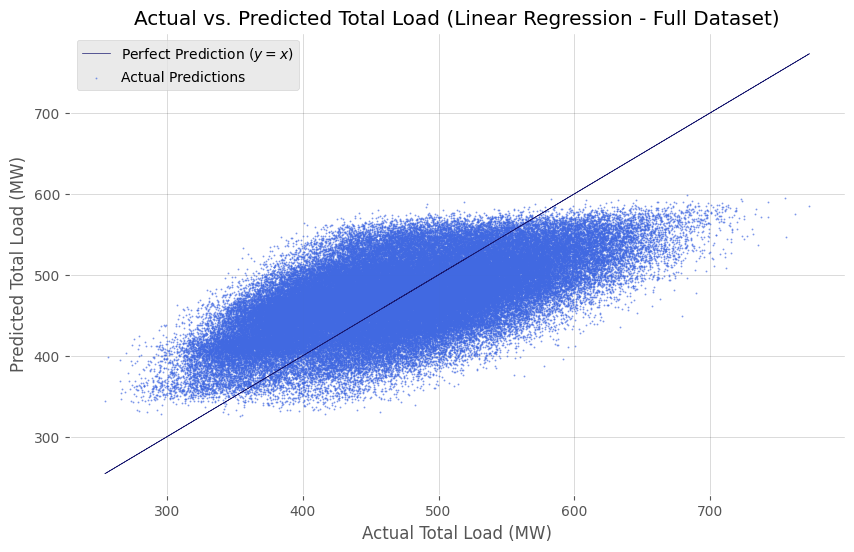

In [323]:
# 6. Plotting
plt.figure(figsize=(10, 6))
# Use 'y' (actuals from full dataset) instead of 'y_test'
# Note: For the perfect prediction line, we plot y vs y. 
# Ideally, for a clean line, you might use [y.min(), y.max()], [y.min(), y.max()]
plt.plot(y, y, color='midnightblue', linewidth=0.5, label='Perfect Prediction ($y=x$)') 
plt.scatter(y, y_pred, s=0.8, alpha=0.5, label='Actual Predictions', color='royalblue')

plt.xlabel('Actual Total Load (MW)')
plt.ylabel('Predicted Total Load (MW)')
plt.title('Actual vs. Predicted Total Load (Linear Regression - Full Dataset)')
plt.legend()

plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()

In [324]:
df=pd.read_csv("C:/Users/mohit/Desktop/capstone project/tata_power_modified_patterns.csv")

In [325]:
# Display the number of rows and columns in the DataFrame
print("DataFrame shape:", df.shape)

DataFrame shape: (105264, 28)


In [326]:
# Display a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105264 entries, 0 to 105263
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   timestamp                   105264 non-null  object 
 1   region                      105264 non-null  object 
 2   day_of_week                 105264 non-null  object 
 3   month                       105264 non-null  int64  
 4   holiday_flag                105264 non-null  int64  
 5   day_type                    105264 non-null  object 
 6   temperature_c               105264 non-null  float64
 7   humidity_%                  105264 non-null  float64
 8   wind_speed_mps              105264 non-null  float64
 9   rainfall_mm                 105264 non-null  float64
 10  solar_irradiance_wm2        105264 non-null  float64
 11  residential_load_mw         105264 non-null  float64
 12  industrial_load_mw          105264 non-null  float64
 13  total_load_mw 

In [327]:
# Generate descriptive statistics of the numerical columns in the DataFrame
display(df.describe())

,month,holiday_flag,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%
count,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.0,105264.000000,105264.000000,105264.000000,105264.000000,1.052640e+05,105264.000000,105264.000000
mean,6.519836,0.002736,30.871772,54.990941,2.007768,0.240371,317.926746,209.741478,262.286860,472.028338,18.913525,7.512837,0.325544,7.173341,49.999910,227.350197,230.0,-1.152088,0.949449,0.877599,77.502332,1.837410e+06,185385.535834,38.303030
std,3.449567,0.052235,4.659756,11.703065,0.980533,0.875749,385.906723,34.154529,46.521426,75.608183,9.089649,6.352251,0.401682,3.581548,0.100435,4.996079,0.0,2.172208,0.028804,0.036034,11.957559,8.766759e+05,37201.708160,8.025618
min,1.000000,0.000000,17.942351,30.000000,0.000000,0.000000,0.000000,105.245114,112.761552,254.087665,9.365697,-16.573227,0.000000,0.000000,49.558482,210.000000,230.0,-8.695652,0.850000,0.827415,59.500002,6.787720e+05,10224.000000,25.178637
25%,4.000000,0.000000,26.961975,45.178711,1.322857,0.000000,0.000000,183.674104,228.205587,414.937871,13.629080,6.184541,0.000000,4.670426,49.932284,223.966359,230.0,-2.623322,0.929946,0.852290,67.003549,6.867230e+05,200000.000000,31.446692
50%,7.000000,0.000000,30.863408,54.980053,1.998385,0.000000,0.203573,208.657241,259.450892,469.095412,14.756715,9.255380,0.000169,7.082021,49.999849,227.348714,230.0,-1.152733,0.950050,0.867771,77.500007,2.035706e+06,200000.000000,39.473659
75%,10.000000,0.000000,34.841897,64.850960,2.674177,0.052535,706.962775,234.049413,293.985932,525.454518,16.585794,11.604643,0.709187,9.545443,50.067677,230.747794,230.0,0.325128,0.970377,0.889047,87.993244,2.735241e+06,200000.000000,45.043883
max,12.000000,1.000000,42.581695,88.382015,6.329187,19.108328,999.999917,333.466317,453.882516,773.357919,43.926860,20.000000,1.273524,25.288309,50.425333,240.000000,230.0,4.347826,1.000000,0.966397,95.499999,2.852315e+06,200000.000000,49.201652


In [328]:
# Convert the 'timestamp' column to datetime objects. 'dayfirst=True' is used
# because the format 'DD-MM-YYYY HH:MM' is implied by the head output.
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Set the 'timestamp' column as the DataFrame's index
df = df.set_index('timestamp')

In [329]:
# Extract the day of the week (0=Monday, 6=Sunday) and hour from the timestamp index
df['weekday'] = df.index.weekday
df['hour'] = df.index.hour

In [330]:
# Create a copy of the DataFrame for machine learning specific preprocessing
df_ml = df.copy()

In [331]:
# Drop the original 'day_of_week' column as a new 'weekday' column (numerical) has been created
df_ml.drop("day_of_week", axis=1, inplace=True)

# Convert 'day_type' categorical column to numerical using one-hot encoding (0 for Weekday, 1 for Weekend)
df_ml["day_type"] = df_ml["day_type"].map({"Weekday": 0, "Weekend": 1})

In [332]:
# Drop the 'region' column as it's a categorical string column not directly used in the current model
# If multiple regions existed, one-hot encoding would be necessary.
df_ml.drop("region", axis=1, inplace=True)

### Initial Data Inspection

Now that the data is loaded, let's perform some initial inspection to understand its structure, size, and content.

In [333]:
# Display the number of rows and columns in the DataFrame
print("DataFrame shape:", df.shape)

DataFrame shape: (105264, 29)


In [334]:
# Display the first 5 rows of the DataFrame to get a glimpse of the data
display(df.head())

,region,day_of_week,month,holiday_flag,day_type,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%,weekday,hour
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,Mumbai,Sunday,1,0,Weekend,26.884441,45.739484,0.000000,0.0,0.000000,179.131751,280.165048,459.296799,14.182997,12.629283,0.000000,0.000000,50.195235,224.806153,230,-2.258194,0.996301,0.869633,67.321351,686723,22450,39.126688,6,0
2023-01-01 01:00:00,Mumbai,Sunday,1,0,Weekend,28.325968,48.624567,1.908234,0.0,196.945317,207.692798,309.077183,516.769981,11.895278,11.155567,0.168918,6.897531,49.978635,224.581335,230,-2.355941,0.922105,0.869647,67.140755,686723,22507,39.126688,6,1
2023-01-01 02:00:00,Mumbai,Sunday,1,0,Weekend,28.296852,57.157680,2.421967,0.0,443.984506,204.636827,298.119795,502.756623,13.486184,10.984116,0.380803,8.754527,50.069858,233.783459,230,1.644982,0.938103,0.869661,67.183766,686723,22526,39.126688,6,2
2023-01-01 03:00:00,Mumbai,Sunday,1,0,Weekend,29.039070,57.812578,2.307619,0.0,660.766885,207.896736,326.578611,534.475348,13.852248,15.149071,0.566739,8.341246,49.982073,233.974838,230,1.728190,0.982882,0.869676,67.165819,686723,22612,39.126688,6,3
2023-01-01 04:00:00,Mumbai,Sunday,1,0,Weekend,27.458422,47.206830,0.689353,0.0,832.519093,185.122870,234.093951,419.216821,13.284986,5.386399,0.714055,2.491786,49.966179,231.207804,230,0.525132,0.955699,0.869690,66.548631,686723,22656,39.126688,6,4


In [335]:
# Display a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105264 entries, 2023-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   region                      105264 non-null  object 
 1   day_of_week                 105264 non-null  object 
 2   month                       105264 non-null  int64  
 3   holiday_flag                105264 non-null  int64  
 4   day_type                    105264 non-null  object 
 5   temperature_c               105264 non-null  float64
 6   humidity_%                  105264 non-null  float64
 7   wind_speed_mps              105264 non-null  float64
 8   rainfall_mm                 105264 non-null  float64
 9   solar_irradiance_wm2        105264 non-null  float64
 10  residential_load_mw         105264 non-null  float64
 11  industrial_load_mw          105264 non-null  float64
 12  total_load_mw               105264 non

In [336]:
# Generate descriptive statistics of the numerical columns in the DataFrame
display(df.describe())

,month,holiday_flag,temperature_c,humidity_%,wind_speed_mps,rainfall_mm,solar_irradiance_wm2,residential_load_mw,industrial_load_mw,total_load_mw,ev_charging_load_mw,battery_storage_mw,solar_generation_mw,wind_generation_mw,grid_frequency_hz,grid_voltage_v,nominal_voltage_v,voltage_fluctuation_%,power_factor,appliance_saturation_index,smart_meter_penetration_%,region_population,electric_vehicle_count,renewable_share_target_%,weekday,hour
count,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.000000,105264.0,105264.000000,105264.000000,105264.000000,105264.000000,1.052640e+05,105264.000000,105264.000000,105264.000000,105264.000000
mean,6.519836,0.002736,30.871772,54.990941,2.007768,0.240371,317.926746,209.741478,262.286860,472.028338,18.913525,7.512837,0.325544,7.173341,49.999910,227.350197,230.0,-1.152088,0.949449,0.877599,77.502332,1.837410e+06,185385.535834,38.303030,2.997264,11.500000
std,3.449567,0.052235,4.659756,11.703065,0.980533,0.875749,385.906723,34.154529,46.521426,75.608183,9.089649,6.352251,0.401682,3.581548,0.100435,4.996079,0.0,2.172208,0.028804,0.036034,11.957559,8.766759e+05,37201.708160,8.025618,2.003425,6.922219
min,1.000000,0.000000,17.942351,30.000000,0.000000,0.000000,0.000000,105.245114,112.761552,254.087665,9.365697,-16.573227,0.000000,0.000000,49.558482,210.000000,230.0,-8.695652,0.850000,0.827415,59.500002,6.787720e+05,10224.000000,25.178637,0.000000,0.000000
25%,4.000000,0.000000,26.961975,45.178711,1.322857,0.000000,0.000000,183.674104,228.205587,414.937871,13.629080,6.184541,0.000000,4.670426,49.932284,223.966359,230.0,-2.623322,0.929946,0.852290,67.003549,6.867230e+05,200000.000000,31.446692,1.000000,5.750000
50%,7.000000,0.000000,30.863408,54.980053,1.998385,0.000000,0.203573,208.657241,259.450892,469.095412,14.756715,9.255380,0.000169,7.082021,49.999849,227.348714,230.0,-1.152733,0.950050,0.867771,77.500007,2.035706e+06,200000.000000,39.473659,3.000000,11.500000
75%,10.000000,0.000000,34.841897,64.850960,2.674177,0.052535,706.962775,234.049413,293.985932,525.454518,16.585794,11.604643,0.709187,9.545443,50.067677,230.747794,230.0,0.325128,0.970377,0.889047,87.993244,2.735241e+06,200000.000000,45.043883,5.000000,17.250000
max,12.000000,1.000000,42.581695,88.382015,6.329187,19.108328,999.999917,333.466317,453.882516,773.357919,43.926860,20.000000,1.273524,25.288309,50.425333,240.000000,230.0,4.347826,1.000000,0.966397,95.499999,2.852315e+06,200000.000000,49.201652,6.000000,23.000000


In [337]:
'''# Convert the 'timestamp' column to datetime objects. 'dayfirst=True' is used
# because the format 'DD-MM-YYYY HH:MM' is implied by the head output.
df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)

# Set the 'timestamp' column as the DataFrame's index
df = df.set_index('timestamp')
'''

"# Convert the 'timestamp' column to datetime objects. 'dayfirst=True' is used\n# because the format 'DD-MM-YYYY HH:MM' is implied by the head output.\ndf['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True)\n\n# Set the 'timestamp' column as the DataFrame's index\ndf = df.set_index('timestamp')\n"

In [338]:
# Verify the data types after converting 'timestamp' and setting it as index
display(df.dtypes)

region                         object
day_of_week                    object
month                           int64
holiday_flag                    int64
day_type                       object
temperature_c                 float64
humidity_%                    float64
wind_speed_mps                float64
rainfall_mm                   float64
solar_irradiance_wm2          float64
residential_load_mw           float64
industrial_load_mw            float64
total_load_mw                 float64
ev_charging_load_mw           float64
battery_storage_mw            float64
solar_generation_mw           float64
wind_generation_mw            float64
grid_frequency_hz             float64
grid_voltage_v                float64
nominal_voltage_v               int64
voltage_fluctuation_%         float64
power_factor                  float64
appliance_saturation_index    float64
smart_meter_penetration_%     float64
region_population               int64
electric_vehicle_count          int64
renewable_sh

In [339]:
# Extract the day of the week (0=Monday, 6=Sunday) and hour from the timestamp index
df['weekday'] = df.index.weekday
df['hour'] = df.index.hour

In [340]:
# Create a copy of the DataFrame for machine learning specific preprocessing
df_ml = df.copy()

In [341]:
# Drop the original 'day_of_week' column as a new 'weekday' column (numerical) has been created
df_ml.drop("day_of_week", axis=1, inplace=True)

# Convert 'day_type' categorical column to numerical using one-hot encoding (0 for Weekday, 1 for Weekend)
df_ml["day_type"] = df_ml["day_type"].map({"Weekday": 0, "Weekend": 1})

In [342]:
# Drop the 'region' column as it's a categorical string column not directly used in the current model
# If multiple regions existed, one-hot encoding would be necessary.
df_ml.drop("region", axis=1, inplace=True)

### Model Training and Evaluation (XGBoost)

Now, let's prepare the data for machine learning and train an XGBoost Regressor to predict `total_load_mw`.

In [343]:
# Define the features (X_cols) and the target variable (total_load_mw)
base_features = [
    "temperature_c", "humidity_%", "rainfall_mm",
    "solar_irradiance_wm2", "day_type", "month", "holiday_flag",
    'solar_generation_mw', 'wind_generation_mw', 'voltage_fluctuation_%',
    'renewable_share_target_%', 'appliance_saturation_index', 'smart_meter_penetration_%',
    'hour' # Include newly created weekday and hour features
]

target = "total_load_mw"

X_cols = base_features # The final list of features to be used

# Assign features to X and target to y from the preprocessed dataframe (df_ml)
X = df_ml[X_cols]
y = df_ml[target]

In [344]:
# Split the data into training and testing sets
# 80% for training, 20% for testing, with a fixed random_state for reproducibility
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [345]:
# Initialize a StandardScaler to scale the numerical features
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
scaler.fit(X_train[X_cols])

# Create scaled copies of the training and testing feature sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Apply the scaling transformation to the selected features in both training and testing sets
X_train_scaled[X_cols] = scaler.transform(X_train[X_cols])
X_test_scaled[X_cols] = scaler.transform(X_test[X_cols])

In [346]:
# Initialize the XGBoost Regressor model
# n_estimators: number of boosting rounds, learning_rate: step size shrinkage, random_state for reproducibility
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the XGBoost model using the scaled training data
model.fit(X_train_scaled, Y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [347]:
# Make predictions on the scaled test set using the trained XGBoost model
Y_pred = model.predict(X_test_scaled)

In [348]:
# Evaluate the model's performance using Mean Absolute Error (MAE) and R2 Score
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))

MAE: 21.855204906591513
R2 Score: 0.8686145852370222


In [349]:
# Initialize a StandardScaler to scale the numerical features
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage
scaler.fit(X[X_cols])

# Create scaled copies of the training and testing feature sets
X_scaled = X.copy()

# Apply the scaling transformation to the selected features in both training and testing sets
X_scaled[X_cols] = scaler.transform(X[X_cols])

# Initialize the XGBoost Regressor model
# n_estimators: number of boosting rounds, learning_rate: step size shrinkage, random_state for reproducibility
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the XGBoost model using the scaled training data
model.fit(X_scaled, y)

# Make predictions on the scaled test set using the trained XGBoost model
Y_pred = model.predict(X_scaled)

# Evaluate the model's performance using Mean Absolute Error (MAE) and R2 Score
print("MAE:", mean_absolute_error(y, Y_pred))
print("R2 Score:", r2_score(y, Y_pred))

MAE: 21.157631245744955
R2 Score: 0.8753026255798251


### Prediction on New Data

Let's test the trained XGBoost model with a sample new data point.

In [350]:
# Create a new DataFrame for a single prediction example
new_data = pd.DataFrame([{
    "temperature_c": 40,
    "humidity_%": 40,
    "rainfall_mm": 0,
    "solar_irradiance_wm2": 300,
    "day_type": 1, # Weekend
    "month": 12,
    "holiday_flag": 0,
    'solar_generation_mw': 0.3,
    'wind_generation_mw': 0.6,
    'voltage_fluctuation_%': 1,
    'renewable_share_target_%': 30,
    'appliance_saturation_index': 0.8,
    'smart_meter_penetration_%': 60,
    #'weekday': 6, # Sunday
    'hour': 18 # 6 PM
}])

# Scale the new_data using the same scaler that was fitted on the training data
new_data_scaled = new_data.copy()
new_data_scaled[X_cols] = scaler.transform(new_data[X_cols])

# Make a prediction using the scaled new data
prediction = model.predict(new_data_scaled)
print("Prediction for new data:", prediction[0])

Prediction for new data: 466.8238


### Visualization of Actual vs. Predicted Values

Finally, let's visualize how well our XGBoost model's predictions align with the actual values in the test set.

In [351]:
'''
# Create a scatter plot to compare actual vs. predicted total load
plt.figure(figsize=(10, 6))
# Plot a 45-degree line representing perfect predictions (where Y_test == Y_pred)
plt.plot(Y_test, Y_test, color='midnightblue', linewidth = 0.5,label='Perfect Prediction ($y=x$)')
# Plot the actual predictions against the true values
plt.scatter(Y_test, Y_pred, s=1, alpha=0.75, label='Actual Predictions', color='royalblue')

plt.xlabel('Actual Total Load (MW)')
plt.ylabel('Predicted Total Load (MW)')
plt.title('Actual vs. Predicted Total Load (XGBoost Regressor)')
plt.legend()
plt.grid(True)
plt.show()
'''

"\n# Create a scatter plot to compare actual vs. predicted total load\nplt.figure(figsize=(10, 6))\n# Plot a 45-degree line representing perfect predictions (where Y_test == Y_pred)\nplt.plot(Y_test, Y_test, color='midnightblue', linewidth = 0.5,label='Perfect Prediction ($y=x$)')\n# Plot the actual predictions against the true values\nplt.scatter(Y_test, Y_pred, s=1, alpha=0.75, label='Actual Predictions', color='royalblue')\n\nplt.xlabel('Actual Total Load (MW)')\nplt.ylabel('Predicted Total Load (MW)')\nplt.title('Actual vs. Predicted Total Load (XGBoost Regressor)')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

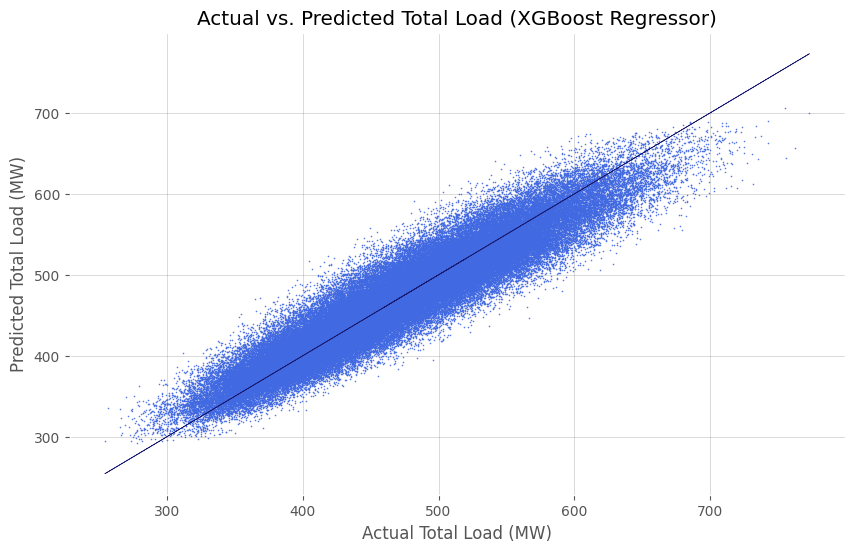

In [352]:
# Create a scatter plot to compare actual vs. predicted total load
plt.figure(figsize=(10, 6))
# Plot a 45-degree line representing perfect predictions (where Y_test == Y_pred)
plt.plot(y, y, color='midnightblue', linewidth = 0.5,label='Perfect Prediction ($y=x$)')
# Plot the actual predictions against the true values
plt.scatter(y, Y_pred, s=0.5, alpha=0.75, label='Actual Predictions', color='royalblue')

plt.xlabel('Actual Total Load (MW)')
plt.ylabel('Predicted Total Load (MW)')
plt.title('Actual vs. Predicted Total Load (XGBoost Regressor)')


plt.gca().set_facecolor('white')
plt.grid(True, color='black', alpha=0.2, linewidth=0.5 )
plt.show()